In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from scipy.stats import wilcoxon


In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent.parent))
from config import raw_data, control_data, external_data, raw_kyiv, filtered_data, daily_data

In [3]:
war_date = pd.to_datetime("2022-02-24")
window = 180  

exclude_donors = [
    "06b923ca-4d2d-44bb-8b20-4e2c9b08ce9f",
    "179bbc95-ec8b-4a65-98c5-5d3b566806fa",
]

In [4]:
base = daily_data

metrics = {
    "Messages": ("donor_daily_message_count", base / "donor_daily_message_count.csv"),
    "Active chats": ("daily_active_chats", base / "daily_active_chats.csv"),
    "Active hours": ("donor_daily_active_hours", base / "donor_daily_active_hours.csv"),
    "Word count": ("donor_daily_word_count", base / "donor_daily_word_count.csv"),
    "Reactions": ("donor_daily_reaction_count", base / "donor_daily_reactions.csv")
}


In [5]:
results  = {}  
all_p = []
all_keys = []

for label, (col, fpath) in metrics.items():
    df_m = pd.read_csv(fpath)
    df_m["date"] = pd.to_datetime(df_m["date"])
    df_m = df_m[~df_m["donation_id"].isin(exclude_donors)]

    for donor_id, grp in df_m.groupby("donation_id"):
        grp = grp.set_index("date").sort_index()

        full_range = pd.date_range(
            war_date - pd.Timedelta(days=window),
            war_date + pd.Timedelta(days=window)
        )
        grp = grp.reindex(full_range)

        pre_vals, post_vals = [], []
        for d in range(1, window + 1):
            pre = grp.loc[war_date - pd.Timedelta(days=d), col]
            post = grp.loc[war_date + pd.Timedelta(days=d), col]

            if not np.isnan(pre) and not np.isnan(post):
                pre_vals.append(pre)
                post_vals.append(post)

        if len(pre_vals) < 10:
            results[(label, donor_id)] = (np.nan, np.nan)
            continue

        _, p_val = wilcoxon(pre_vals, post_vals)
        direction = np.mean(np.array(post_vals) - np.array(pre_vals))
        results[(label, donor_id)] = (direction, p_val)
        all_p.append(p_val)
        all_keys.append((label, donor_id))

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Sample size too small for normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_f

#### Bonferroni correction

In [6]:
n_tests = len(all_p)
p_corrected = {k: min(p * n_tests, 1.0) for k, p in zip(all_keys, all_p)}

n_sig_pos = sum(1 for k in all_keys
                if p_corrected[k] < 0.05 and results[k][0] > 0)
n_sig_neg = sum(1 for k in all_keys
                if p_corrected[k] < 0.05 and results[k][0] < 0)

print(f"Total tests: {n_tests}")
print(f"Significant positive: {n_sig_pos} (increased after war)")
print(f"Significant negative: {n_sig_neg} (decreased after war)")
print(f"Not significant: {n_tests - n_sig_pos - n_sig_neg}")


Total tests: 104
Significant positive: 28 (increased after war)
Significant negative: 13 (decreased after war)
Not significant: 63


In [7]:
metrics = list(metrics.keys())
donors = sorted(set(d for _, d in all_keys))
donor_labels = [d[:8] for d in donors]

sig_matrix = np.zeros((len(metrics), len(donors)), dtype=float)
t_matrix = np.full((len(metrics), len(donors)), np.nan)

for i, label in enumerate(metrics):
    for j, donor_id in enumerate(donors):
        key = (label, donor_id)
        if key not in results:
            continue
        t_stat, _ = results[key]
        if np.isnan(t_stat):
            continue
        t_matrix[i, j] = t_stat
        if p_corrected.get(key, 1.0) < 0.05:
            sig_matrix[i, j] = 1.0 if t_stat > 0 else -1.0


#### Heatmap

/var/folders/vx/kbkdd94d7092nh7qby2pf8lr0000gn/T/ipykernel_52406/2520593764.py:39: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color="#F0F0F0", label="Not significant", edgecolor="lightgray"),


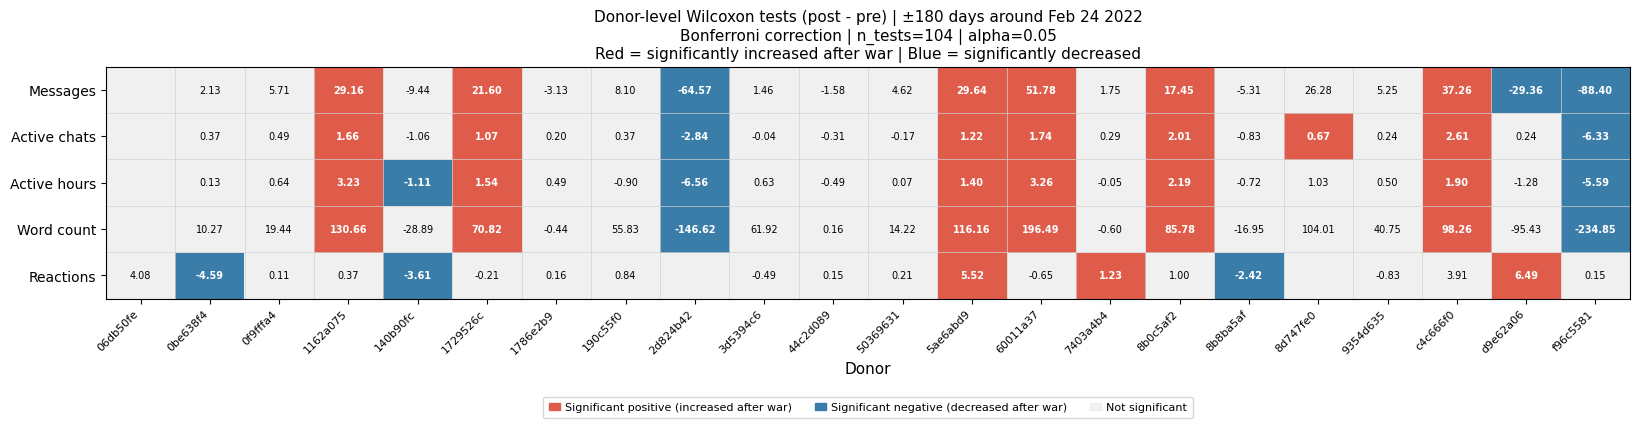

In [8]:
cmap = ListedColormap(["#3A7DA9", "#F0F0F0", "#E05C4A"]) 

fig, ax = plt.subplots(figsize=(max(14, len(donors) * 0.75), len(metrics) * 0.6 + 2))

ax.imshow(sig_matrix, aspect="auto", cmap=cmap, vmin=-1, vmax=1)

ax.set_xticks(np.arange(-0.5, len(donors), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(metrics), 1), minor=True)
ax.grid(which="minor", color="lightgray", linewidth=0.5)
ax.tick_params(which="minor", bottom=False, left=False)

for i in range(len(metrics)):
    for j in range(len(donors)):
        t = t_matrix[i, j]
        if np.isnan(t):
            continue
        sig = sig_matrix[i, j]
        ax.text(j, i, f"{t:.2f}",
                ha="center", va="center", fontsize=7,
                color="white" if sig != 0 else "#000000",
                fontweight="bold" if sig != 0 else "normal")

ax.set_xticks(range(len(donors)))
ax.set_xticklabels(donor_labels, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(metrics)))
ax.set_yticklabels(metrics, fontsize=10)
ax.set_xlabel("Donor", fontsize=11)

ax.set_title(
    f"Donor-level Wilcoxon tests (post - pre) | ±{window} days around Feb 24 2022\n"
    f"Bonferroni correction | n_tests={n_tests} | alpha=0.05\n"
    "Red = significantly increased after war | Blue = significantly decreased",
    fontsize=11
)

patches = [
    mpatches.Patch(color="#E05C4A", label="Significant positive (increased after war)"),
    mpatches.Patch(color="#3A7DA9", label="Significant negative (decreased after war)"),
    mpatches.Patch(color="#F0F0F0", label="Not significant", edgecolor="lightgray"),
]
ax.legend(handles=patches, loc="upper center",
          bbox_to_anchor=(0.5, -0.4), fontsize=8, frameon=True,
          ncol=3, handlelength=1, handletextpad=0.5, borderpad=0.5)

plt.tight_layout()
plt.show()